# $\nu_e$ CC Inclusive Selection (v2-2)

In [1]:
# =============================================================================
# CELL 0 — imports & paths
# =============================================================================
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./plots_syst_v1"
DF_OUT_DIR   = "./nuecc_dfs"
# DF_FILE      = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_2605.df"
DF_FILE = "/home/castalyf/cafpyana_out/mc1e20_nueCC_test_small.df"
TARGET_POT   = 6.6e20
TITLE        = r"SBND $\nu_e$ CC Inclusive"

os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

import nue_helpers   as nh
import nue_selection as ns
%load_ext autoreload
%autoreload 2


In [2]:
# SEL_TOPO_FILE = os.path.join(PLOT_DIR, "selected_nuecc_topo.df")
# SEL_QUAL_FILE = os.path.join(PLOT_DIR, "selected_nuecc_qual.df")
# sel_topo  = nh.load_selection(SEL_TOPO_FILE)
# sel_qual  = nh.load_selection(SEL_QUAL_FILE)
# truth_info = pd.read_hdf(MERGED_FILE, key="truth_info_0")
# pot_scale  = float(sel_topo["pot_scale"].iloc[0])

## 1. Check the keys in the sample

In [3]:
# import os
# import pandas as pd

# print("=== MC_FILE diagnostics ===")
# print(f"MC_FILE = {MC_FILE!r}")
# print(f"File exists?          {os.path.exists(MC_FILE)}")
# print(f"File size (bytes)     {os.path.getsize(MC_FILE) if os.path.exists(MC_FILE) else 'N/A'}")
# print(f"Is file?              {os.path.isfile(MC_FILE)}")

# try:
#     with pd.HDFStore(MC_FILE, mode='r') as store:
#         print(f"Available keys:       {store.keys()}")
#         print(f"Number of keys:       {len(store.keys())}")
# except Exception as e:
#     print(f"Error opening HDFStore: {e}")

## 2. Load the data frame

In [4]:
with pd.HDFStore(DF_FILE, mode="r") as store:
    keys = store.keys()
    print(f"Keys: {keys}")
    has_split = "/split" in keys

if has_split:
    with pd.HDFStore(DF_FILE, mode="r") as store:
        n_splits = int(store["split"]["n_split"].iloc[0])
    print(f"Split format: {n_splits} splits")
    evt_frames   = [pd.read_hdf(DF_FILE, key=f"evt_{k}")        for k in range(n_splits)]
    stats_frames = [pd.read_hdf(DF_FILE, key=f"stats_{k}")      for k in range(n_splits)]
    hist_frames  = [pd.read_hdf(DF_FILE, key=f"histpotdf_{k}")  for k in range(n_splits)]
else:
    print("Merged format: single tables")
    with pd.HDFStore(DF_FILE, mode="r") as store:
        evt_keys  = sorted([k for k in keys if k.lstrip("/").startswith("evt")])
        stat_keys = sorted([k for k in keys if k.lstrip("/").startswith("stats")])
        hist_keys = sorted([k for k in keys if "histpotdf" in k])
    evt_frames   = [pd.read_hdf(DF_FILE, key=k) for k in evt_keys]
    stats_frames = [pd.read_hdf(DF_FILE, key=k) for k in stat_keys]
    hist_frames  = [pd.read_hdf(DF_FILE, key=k) for k in hist_keys]

evtdf     = pd.concat(evt_frames,   axis=0)
statsdf   = pd.concat(stats_frames, axis=0)
histpotdf = pd.concat(hist_frames,  axis=0) if hist_frames else pd.DataFrame()

print(f"\nevtdf   shape : {evtdf.shape}")
print(f"statsdf shape : {statsdf.shape}")

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/pot_0', '/split', '/stats_0']
Split format: 1 splits

evtdf   shape : (110842, 393)
statsdf shape : (5, 14)


In [5]:
# histpotdf already loaded in Cell 1 — use directly
print("histpotdf columns:", histpotdf.columns.tolist())
print(histpotdf.head())

pot_col   = "TotalPOT" if "TotalPOT" in histpotdf.columns \
            else histpotdf.select_dtypes("number").columns[0]
total_pot = float(histpotdf[pot_col].sum())
pot_scale = TARGET_POT / total_pot if total_pot > 0 else float("nan")

print(f"Total POT    : {total_pot:.3e}")
print(f"Target POT   : {TARGET_POT:.3e}")
print(f"Scale factor : {pot_scale:.4f}")

n_true_signal        = int(statsdf["n_true_signal"].sum())
n_inter_after_fm     = int(statsdf["n_after_fm"].sum())
n_inter_after_presel = int(statsdf["n_after_presel"].sum())
n_sig_after_fm       = int(statsdf["n_sig_after_fm"].sum())
n_sig_after_presel   = int(statsdf["n_sig_after_presel"].sum())

print(f"True signal (pre-cut)   : {n_true_signal:,}  <- denominator")
print(f"Signal after FM         : {n_sig_after_fm:,}  ({n_sig_after_fm/n_true_signal*100:.1f}%)")
print(f"Signal after FM+FV      : {n_sig_after_presel:,}  ({n_sig_after_presel/n_true_signal*100:.1f}%)")

histpotdf columns: ['TotalPOT']
                    TotalPOT
__ntuple entry              
0        0      7.545876e+17
3        0      7.523471e+17
2        0      7.556371e+17
1        0      7.517843e+17
4        0      7.546533e+17
Total POT    : 3.769e+18
Target POT   : 6.600e+20
Scale factor : 175.1123
True signal (pre-cut)   : 113  <- denominator
Signal after FM         : 99  (87.6%)
Signal after FM+FV      : 99  (87.6%)


In [6]:
# visualize the structure

cols = [" -> ".join([str(c) for c in col if c != ""]) for col in evtdf.columns]

# Determine the midpoint
mid = (len(cols) + 1) // 2
left = cols[:mid]
right = cols[mid:]

# Set a fixed width for alignment
width = max(len(c) for c in left) + 4

for l, r in zip(left, right + [""] * (len(left) - len(right))):
    print(f"{l:<{width}}{r}")

###############
# # save a few events into csv 

# subset = evtdf.reset_index().head(100)
# subset.to_csv("evtdf_preview.csv", index=False)
# print("Saved: evtdf_preview.csv")

# interaction_subset = (
#     evtdf
#     .xs((1, 0, 0), level=['__ntuple', 'entry', 'rec.dlp..index'])
#     .reset_index()
# )
# interaction_subset.to_csv("interaction01_preview.csv", index=False)
# print("Saved: interaction01_preview.csv")


# export_df = pd.concat([
#     evtdf["rec"]["dlp_true"]["particles"],
#     evtdf["rec"]["dlp"]["particles"]
# ], axis=1).reset_index()

# export_df.head(1000).to_csv("particle_preview.csv", index=False)
# print("Saved: particle_preview.csv")

rec -> dlp -> match_ids                                    rec -> dlp_true -> particles -> end_dir -> y
rec -> dlp -> match_overlaps                               rec -> dlp_true -> particles -> end_dir -> z
rec -> dlp -> cathode_offset                               rec -> dlp_true -> particles -> end_momentum -> I0
rec -> dlp -> depositions_sum                              rec -> dlp_true -> particles -> end_momentum -> I1
rec -> dlp -> flash_hypo_pe                                rec -> dlp_true -> particles -> end_momentum -> I2
rec -> dlp -> flash_total_pe                               rec -> dlp_true -> particles -> end_p
rec -> dlp -> id                                           rec -> dlp_true -> particles -> end_point -> x
rec -> dlp -> is_cathode_crosser                           rec -> dlp_true -> particles -> end_point -> y
rec -> dlp -> is_contained                                 rec -> dlp_true -> particles -> end_point -> z
rec -> dlp -> is_fiducial                      

## 3. True signal definition

In [7]:
n_true_signal      = int(statsdf["n_true_signal"].sum())
n_inter_after_fm   = int(statsdf["n_after_fm"].sum())       # all interactions after FM
n_inter_after_presel = int(statsdf["n_after_presel"].sum()) # all interactions after FM+FV
n_sig_after_fm     = int(statsdf["n_sig_after_fm"].sum())   # signal after FM
n_sig_after_presel = int(statsdf["n_sig_after_presel"].sum()) # signal after FM+FV

print(f"True signal (pre-cut)   : {n_true_signal:,}  <- denominator")
print(f"Signal after FM         : {n_sig_after_fm:,}  ({n_sig_after_fm/n_true_signal*100:.1f}%)")
print(f"Signal after FM+FV      : {n_sig_after_presel:,}  ({n_sig_after_presel/n_true_signal*100:.1f}%)")
# print(f"Signal visible in evtdf : {len(sig_inter_idx):,}  (should match n_sig_after_presel)")



True signal (pre-cut)   : 113  <- denominator
Signal after FM         : 99  (87.6%)
Signal after FM+FV      : 99  (87.6%)


In [8]:
# =============================================================================
# CELL 3 — alignment helpers (same as before)
# =============================================================================
il               = nh.inter_levels(evtdf)
presel_inter     = evtdf.groupby(level=il).size().index
truth_cat_presel = evtdf.groupby(level=il).first()  # interaction-level view

# NOTE: with the new df, truth_info_0 is not written separately.
# truth categories come from classify_truth or from statsdf aggregate counts.
# For per-interaction truth_cat, use classify_truth:
truth_cat_presel = ns.classify_truth(evtdf, verbose=True)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

sig_inter_idx   = truth_cat_presel[truth_cat_presel == 0].index
sig_mask_presel = presel_inter.isin(sig_inter_idx)

print(f"\nSignal visible in evtdf : {len(sig_inter_idx):,}")
print(f"True denominator        : {n_true_signal:,}")

classify_truth: reading true-interaction flags …
  is_nu        :   22,170
  is_cc        :   17,185
  is_fv (true) :   19,019
  true_elec    :      172
  true_muon    :   16,491
  has_pi0      :    3,083

=== Truth category summary ===
  cat  0  nueCC FV (signal)     :       99
  cat  1  nueCC out FV          :        5
  cat  2  numuCC + π⁰           :    1,784
  cat  3  NC π⁰                 :    1,087
  cat  4  other numuCC          :   14,153
  cat  5  other NC              :    3,898
  cat  6  cosmic                :    1,005
  cat  7  other neutrino        :    1,144
  total                     :   23,175
=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 271
Raw min  : 10.7048
Raw max  : 3501.4021
Raw mean : 620.8404
Raw median: 397.6704
After *1000 (GeV→MeV)  → min/max: 10704.8 – 3501402.1 MeV
After *1     (already MeV) → min/max: 10.7 – 3501.4 MeV

Signal visible in evtdf : 99
True denominator        : 113


## 4. Selection 

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 271
Raw min  : 10.7048
Raw max  : 3501.4021
Raw mean : 620.8404
Raw median: 397.6704
After *1000 (GeV→MeV)  → min/max: 10704.8 – 3501402.1 MeV
After *1     (already MeV) → min/max: 10.7 – 3501.4 MeV

Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)               113     0.00%        100.0%
  Flash match                   40,524     0.24%         87.6%
  In FV                         23,175     0.43%         87.6%
  Final state topology             630    16.67%         83.2%


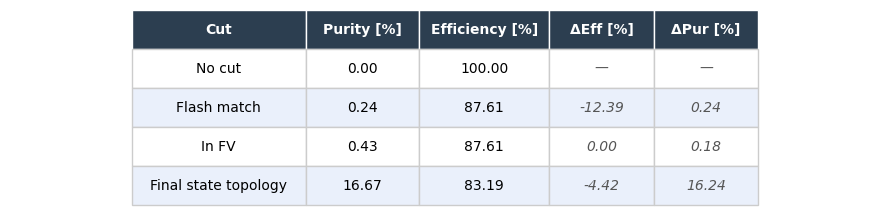

In [9]:
# =============================================================================
# CELL 4 — cut flow + table + save sel_topo  (earliest possible save point)
# =============================================================================
import gc

cut_flow          = ns.build_cut_flow(evtdf)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

def _purity(stage_idx):
    n_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    if n_no7 == 0:
        return float("nan")
    return int((truth_cat_presel.reindex(stage_idx) == 0).sum()) / n_no7

se_idx   = cut_flow["single_electron"]["inter_index"]
n_sig_se = int((truth_cat_presel.reindex(se_idx) == 0).sum())

eff_fm = n_sig_after_fm     / n_true_signal      if n_true_signal      > 0 else float("nan")
eff_fv = n_sig_after_presel / n_true_signal      if n_true_signal      > 0 else float("nan")
eff_se = n_sig_se           / n_true_signal      if n_true_signal      > 0 else float("nan")
pur_fm = n_sig_after_fm     / n_inter_after_fm   if n_inter_after_fm   > 0 else float("nan")
pur_fv = n_sig_after_presel / n_inter_after_presel if n_inter_after_presel > 0 else float("nan")
pur_se = _purity(se_idx)

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_true_signal:>9,}  {'0.00%':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_after_fm:>9,}  {pur_fm*100:>7.2f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_after_presel:>9,}  {pur_fv*100:>7.2f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {len(se_idx):>9,}  {pur_se*100:>7.2f}%  {eff_se*100:>11.1f}%")

CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0, pur_fm, pur_fv, pur_se]
effs_table  = [1.0, eff_fm, eff_fv, eff_se]
fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

In [10]:
# ── Save sel_topo — all evtdf-dependent calls happen exactly once here ────────
os.makedirs(DF_OUT_DIR, exist_ok=True)
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo_v2.df")
_stage_idx_topo = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,
    "fiducial"        : presel_inter,
    "single_electron" : se_idx,
}
sel_topo = nh.build_and_save_selection(
    path             = SEL_TOPO_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    reco_p           = ns.leading_electron_p(evtdf),
    true_ke          = true_ke_all,           # already computed above
    true_cos         = true_costheta_all,     # already computed above
    true_p           = ns.true_leading_electron_p(evtdf),
    stage_idx_dict   = _stage_idx_topo,
    cut_names        = list(_stage_idx_topo.keys()),
    pot_scale        = pot_scale,
)
print(f"sel_topo saved → {SEL_TOPO_FILE}  shape: {sel_topo.shape}")
print(f"  cols: {list(sel_topo.columns)}")
# evtdf still alive — threshold scans need it

Saved selection df → ./nuecc_dfs/selected_nuecc_topo_v2.df
  shape=(23175, 13)  size=0.1 MB
sel_topo saved → ./nuecc_dfs/selected_nuecc_topo_v2.df  shape: (23175, 13)
  cols: ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


### 4-1. Efficiency/purity stats

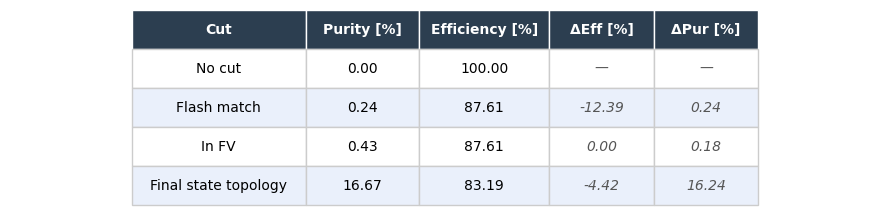

In [11]:
CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0,   pur_fm, pur_fv, pur_se]
effs_table  = [1.0,   eff_fm, eff_fv, eff_se]

fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

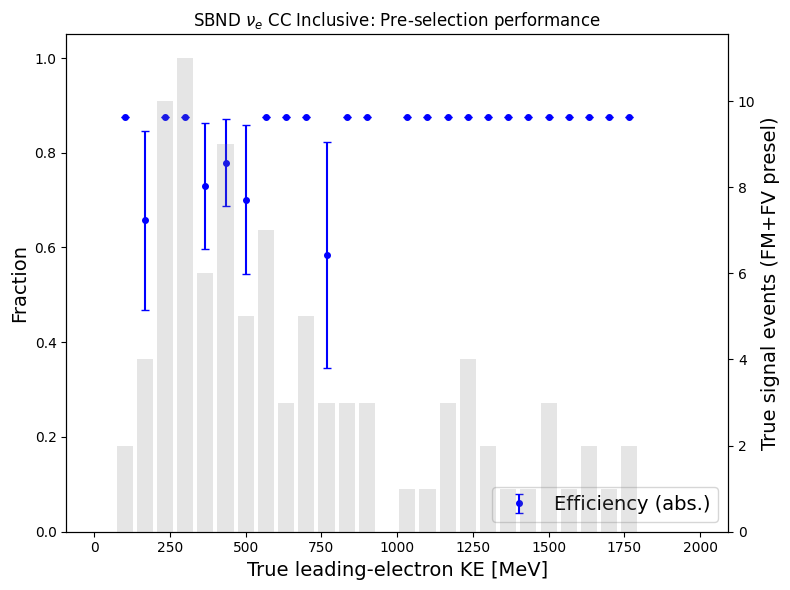

In [12]:
# ── Binned efficiency using statsdf + evtdf (no truth_info needed) ───────────
ke_bins_eff = np.linspace(0, 2000, 31)

# true_ke and signal mask come from evtdf (FM+FV preselected interactions only)
# Non-preselected signal events are accounted for via n_true_signal from statsdf
all_true_ke  = true_ke_all.reindex(presel_inter).fillna(-999).values
all_sig_mask = (truth_cat_presel.reindex(presel_inter).fillna(7) == 0).values
all_sel_mask = presel_inter.isin(cut_flow["single_electron"]["inter_index"])

centers, purs_b, effs_b, counts_b = nh.pur_eff_binned(
    values   = all_true_ke,
    bins     = ke_bins_eff,
    sel_mask = all_sel_mask,
    sig_mask = all_sig_mask,
)

# NOTE: effs_b here is efficiency relative to FM+FV presel signal (not pre-FM/FV).
# Correct the y-axis label accordingly, or scale by n_sig_after_presel/n_true_signal
# to get absolute efficiency relative to the full pre-cut denominator.
abs_eff_scale = n_sig_after_presel / n_true_signal if n_true_signal > 0 else 1.0
effs_b_abs    = effs_b * abs_eff_scale

n       = np.maximum(counts_b, 1)
eff_err = np.sqrt(effs_b * (1 - effs_b) / n) * abs_eff_scale

fig_bin, ax_bin = plt.subplots(figsize=(8, 6))
ax2 = ax_bin.twinx()
ax_bin.errorbar(centers, effs_b_abs, yerr=eff_err,
                fmt="o", color="blue", capsize=3, ms=4, label="Efficiency (abs.)")
ax_bin.set_ylim(0, 1.05)
ax_bin.set_xlabel("True leading-electron KE [MeV]", fontsize=14)
ax_bin.set_ylabel("Fraction", fontsize=14)
ax_bin.set_title(fr"{TITLE}: Pre-selection performance")
ax_bin.legend(fontsize=14, loc="lower right")
ax2.bar(centers, counts_b,
        width=np.diff(centers).mean() * 0.8,
        alpha=0.2, color="gray", label="True signal (presel)")
ax2.set_ylabel("True signal events (FM+FV presel)", fontsize=14)
plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_pur_ke", fig=fig_bin, folder_name=PLOT_DIR)

In [13]:
# # ── Resolution plots from sel_topo ────────────────────────────────────────────
# ke_bins = np.linspace(0, 2000, 41)
# ct_bins = np.linspace(-1, 1,  41)

# # stage index: interactions that passed single_electron topology cut
# stage_idx = sel_topo.index[sel_topo["sel_single_electron"]]

# # signal-only mask (rows in sel_topo that are true signal)
# sig_mask = sel_topo["is_sig"]

# # ── KE resolution ─────────────────────────────────────────────────────────────
# fig_ke, _ = nh.plot_leading_e_resolution(
#     true_series = sel_topo.loc[sig_mask, "true_ke"],
#     reco_series = sel_topo.loc[sig_mask, "reco_ke"],
#     bins        = ke_bins,
#     stage_idx   = stage_idx,
#     xlabel      = "True leading electron KE [MeV]",
#     ylabel      = "Reco leading electron KE [MeV]",
#     normalize   = True,
#     log_color   = True,
#     title       = fr"{TITLE} — KE resolution",
# )
# plt.show()
# nh.save_plot("resolution_ke", fig=fig_ke, folder_name=PLOT_DIR)

# # ── cos θ resolution ───────────────────────────────────────────────────────────
# fig_ct, _ = nh.plot_leading_e_resolution(
#     true_series = sel_topo.loc[sig_mask, "true_costheta"],
#     reco_series = sel_topo.loc[sig_mask, "reco_costheta"],
#     bins        = ct_bins,
#     stage_idx   = stage_idx,
#     xlabel      = r"True leading electron $\cos\theta$",
#     ylabel      = r"Reco leading electron $\cos\theta$",
#     normalize   = False,
#     log_color   = True,
#     title       = fr"{TITLE} — $\cos\theta$ resolution",
# )
# plt.show()
# nh.save_plot("resolution_costheta", fig=fig_ct, folder_name=PLOT_DIR)

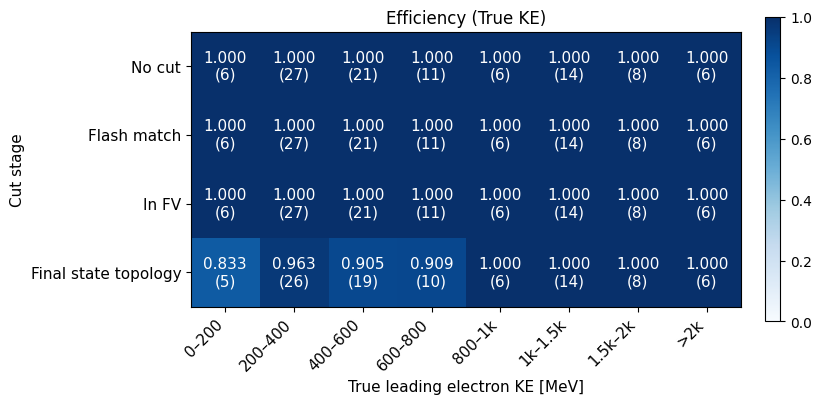

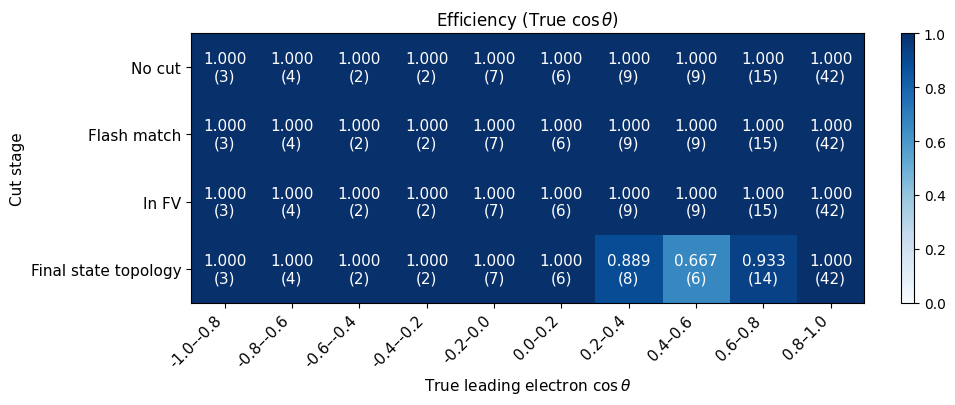

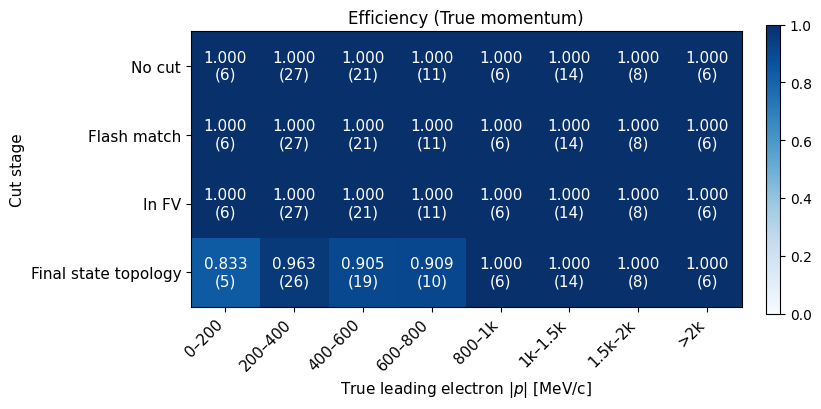

In [14]:
# ── Stage selection masks aligned to presel_inter ────────────────────────────
stage_sel = {
    "precut"          : np.ones(len(presel_inter), dtype=bool),
    "valid_flashmatch": np.ones(len(presel_inter), dtype=bool),  # all presel passed FM
    "fiducial"        : np.ones(len(presel_inter), dtype=bool),  # all presel passed FV
    "single_electron" : presel_inter.isin(cut_flow["single_electron"]["inter_index"]),
}
sig_true_vals = (truth_cat_presel.reindex(presel_inter).fillna(7) == 0).values
n_cuts        = len(ns.CUT_NAMES)

# ── Efficiency matrix: true KE bins × cut stages ─────────────────────────────
ke_bins_c     = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = ["0–200","200–400","400–600","600–800",
                 "800–1k","1k–1.5k","1.5k–2k",">2k"]
n_ke_bins = len(ke_bins_c) - 1
ke_vals   = true_ke_all.reindex(presel_inter).fillna(-999).values

ke_eff_matrix   = np.zeros((n_ke_bins, n_cuts))
ke_count_matrix = np.zeros((n_ke_bins, n_cuts))
for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals >= lo) & (ke_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        ke_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        ke_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    ke_eff_matrix, ke_count_matrix,
    bin_values=np.arange(n_ke_bins), bin_labels=ke_bin_labels,
    cut_labels=ns.CUT_LABELS, remove_dummy_col=False,
    xlabel="True leading electron KE [MeV]", title="Efficiency (True KE)", cmap="Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke", fig=fig, folder_name=PLOT_DIR)

# ── Efficiency matrix: true cos θ ────────────────────────────────────────────
ct_bins_c     = np.array([-1.0,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0])
ct_bin_labels = ["-1.0–-0.8","-0.8–-0.6","-0.6–-0.4","-0.4–-0.2","-0.2–0.0",
                 "0.0–0.2","0.2–0.4","0.4–0.6","0.6–0.8","0.8–1.0"]
n_ct_bins = len(ct_bins_c) - 1
ct_vals   = true_costheta_all.reindex(presel_inter).fillna(-999).values

ct_eff_matrix   = np.zeros((n_ct_bins, n_cuts))
ct_count_matrix = np.zeros((n_ct_bins, n_cuts))
for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(ct_bins_c[:-1], ct_bins_c[1:])):
        in_bin       = (ct_vals >= lo) & (ct_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        ct_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        ct_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    ct_eff_matrix, ct_count_matrix,
    bin_values=np.arange(n_ct_bins), bin_labels=ct_bin_labels,
    cut_labels=ns.CUT_LABELS, remove_dummy_col=False,
    xlabel=r"True leading electron $\cos\theta$",
    title=r"Efficiency (True $\cos\theta$)", cmap="Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_costheta", fig=fig, folder_name=PLOT_DIR)

# ── Efficiency matrix: true |p| ───────────────────────────────────────────────
p_bins_c     = np.array([0,200,400,600,800,1000,1500,2000,np.inf])
p_bin_labels = ["0–200","200–400","400–600","600–800",
                "800–1k","1k–1.5k","1.5k–2k",">2k"]
n_p_bins = len(p_bins_c) - 1
p_vals   = ns.true_leading_electron_p(evtdf).reindex(presel_inter).fillna(-999).values

p_eff_matrix   = np.zeros((n_p_bins, n_cuts))
p_count_matrix = np.zeros((n_p_bins, n_cuts))
for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(p_bins_c[:-1], p_bins_c[1:])):
        in_bin       = (p_vals >= lo) & (p_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        p_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        p_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    p_eff_matrix, p_count_matrix,
    bin_values=np.arange(n_p_bins), bin_labels=p_bin_labels,
    cut_labels=ns.CUT_LABELS, remove_dummy_col=False,
    xlabel=r"True leading electron $|p|$ [MeV/c]",
    title="Efficiency (True momentum)", cmap="Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_p", fig=fig, folder_name=PLOT_DIR)

### 4-2. Histograms

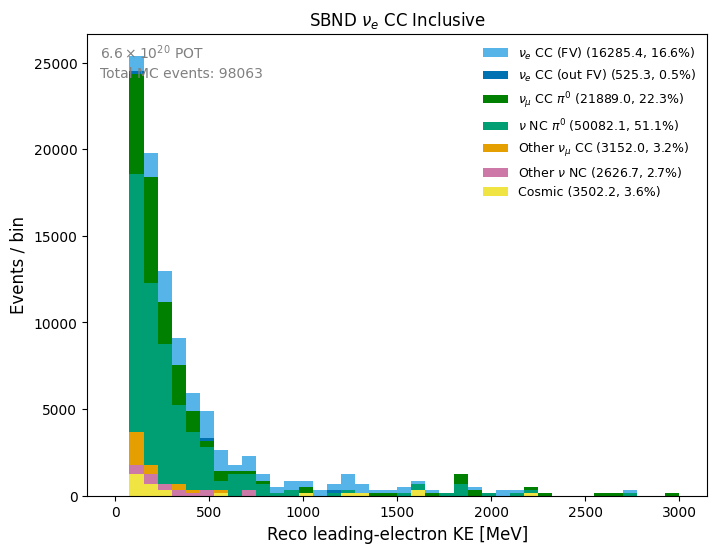

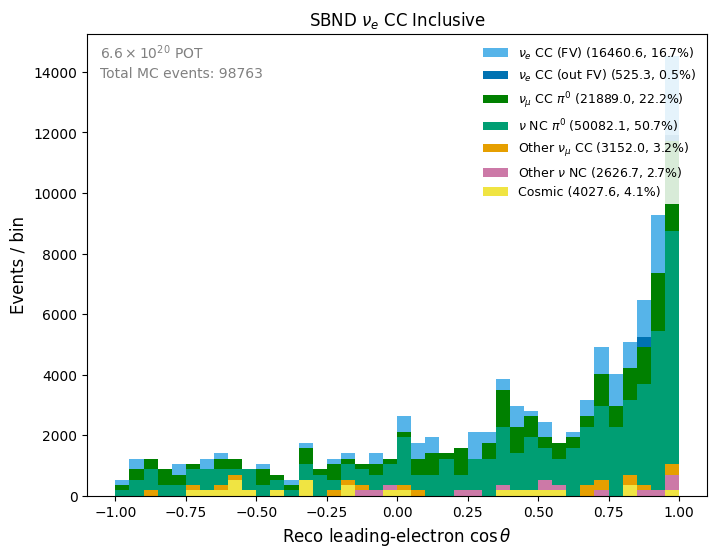

In [15]:
# ── Topology stacked histograms from sel_topo ─────────────────────────────────
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]

def _topo_cat(col, cat):
    mask = sel_topo["sel_single_electron"] & (sel_topo["truth_cat"] == cat)
    return sel_topo.loc[mask, col].dropna().values

_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 3000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke", fig=fig_ke, folder_name=PLOT_DIR)

fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta", fig=fig_cos, folder_name=PLOT_DIR)

## 5. Shower quality cuts

In [16]:
import nue_helpers as nh
import nue_selection as ns

# truth_cat_presel already computed from truth_info in cell 4 — use directly
truth_cats = truth_cat_presel   # replaces: ns.classify_truth(evtdf, verbose=False)



/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1007: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


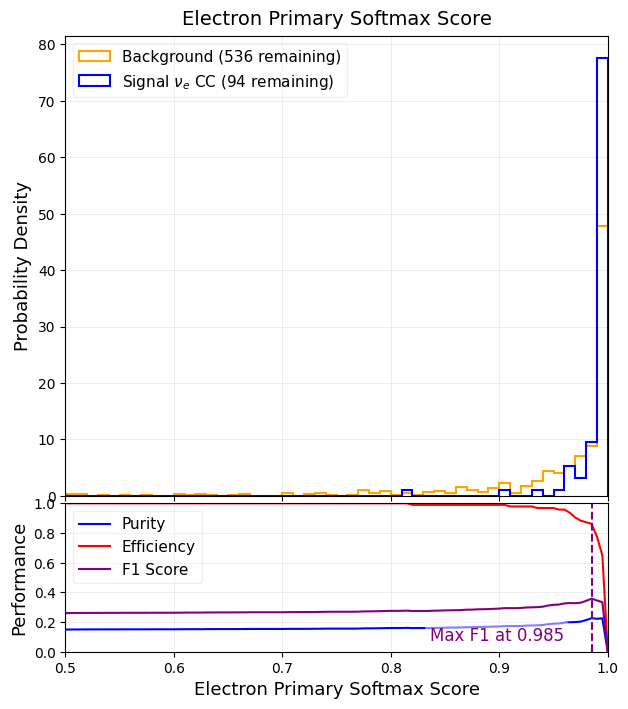


──────────────────────────────────────────────────
  Variable   : primary_scores
  Remaining  : 630 interactions (94 signal, 536 bkg)
  Cut dir    : > 0.9850
  Efficiency : 86.2%  (of remaining signal)
  Purity     : 22.6%
  Max F1     : 0.3576
──────────────────────────────────────────────────



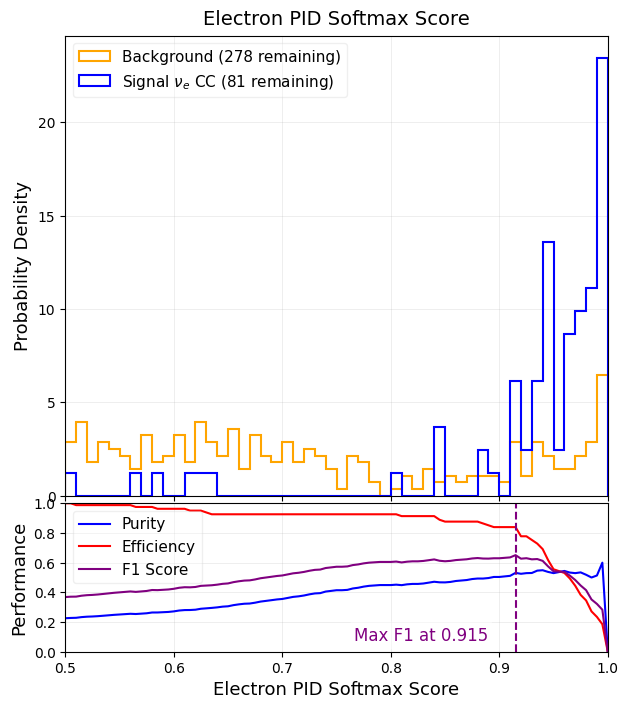


──────────────────────────────────────────────────
  Variable   : pid_scores
  Remaining  : 359 interactions (81 signal, 278 bkg)
  Cut dir    : > 0.9150
  Efficiency : 84.0%  (of remaining signal)
  Purity     : 53.1%
  Max F1     : 0.6507
──────────────────────────────────────────────────



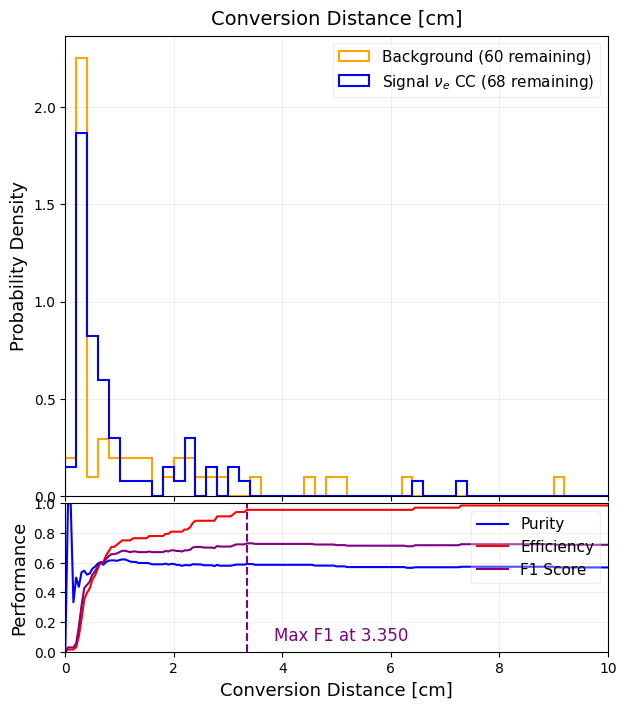


──────────────────────────────────────────────────
  Variable   : vertex_distance
  Remaining  : 128 interactions (68 signal, 60 bkg)
  Cut dir    : < 3.3500
  Efficiency : 95.6%  (of remaining signal)
  Purity     : 59.1%
  Max F1     : 0.7303
──────────────────────────────────────────────────



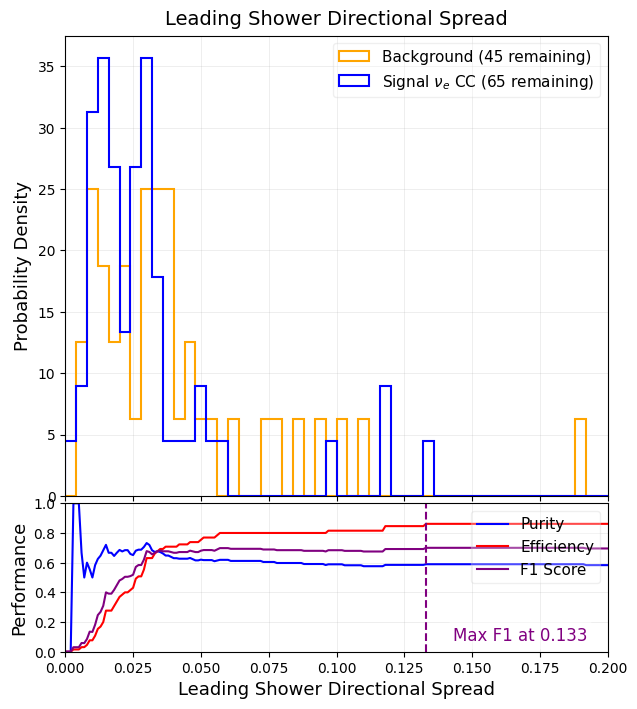


──────────────────────────────────────────────────
  Variable   : directional_spread
  Remaining  : 110 interactions (65 signal, 45 bkg)
  Cut dir    : < 0.1330
  Efficiency : 86.2%  (of remaining signal)
  Purity     : 58.9%
  Max F1     : 0.7000
──────────────────────────────────────────────────



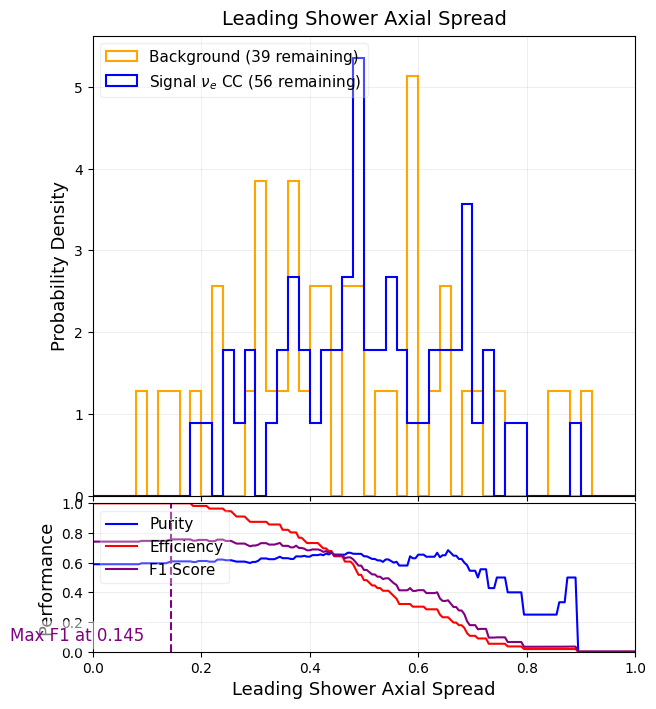


──────────────────────────────────────────────────
  Variable   : axial_spread
  Remaining  : 95 interactions (56 signal, 39 bkg)
  Cut dir    : > 0.1450
  Efficiency : 100.0%  (of remaining signal)
  Purity     : 60.9%
  Max F1     : 0.7568
──────────────────────────────────────────────────



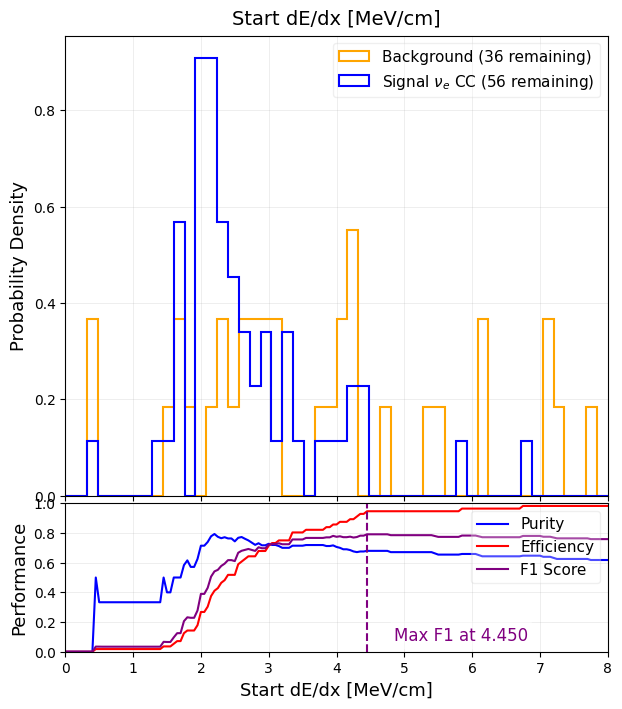


──────────────────────────────────────────────────
  Variable   : start_dedx
  Remaining  : 92 interactions (56 signal, 36 bkg)
  Cut dir    : < 4.4500
  Efficiency : 94.6%  (of remaining signal)
  Purity     : 67.9%
  Max F1     : 0.7910
──────────────────────────────────────────────────


Final surviving interactions: 78

Optimal thresholds (cumulative):
  primary_scores                : 0.9850
  pid_scores                    : 0.9150
  vertex_distance               : 3.3500
  directional_spread            : 0.1330
  axial_spread                  : 0.1450
  start_dedx                    : 4.4500


In [17]:
import nue_helpers as nh

shower_cuts = [
    ("primary_scores",     [0.5, 1.0], "Electron Primary Softmax Score",     [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_primary_score"),
    ("pid_scores",         [0.5, 1.0], "Electron PID Softmax Score",        [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_pid_score"),
    ("vertex_distance",    [0.0, 10.], "Conversion Distance [cm]",           [0.0, 10.0, 0.05],  '<',  'right', "f1_thrsh_vertex_distance"),
    ("directional_spread", [0.0, 0.2], "Leading Shower Directional Spread",  [0.0, 0.2,  0.001], '<',  'right', "f1_thrsh_directional_spread"),
    ("axial_spread",       [0.0, 1.0], "Leading Shower Axial Spread",        [0.0, 1.0,  0.005], '>',  'left',  "f1_thrsh_axial_spread"),
    ("start_dedx",         [0.0, 8.0], "Start dE/dx [MeV/cm]",              [0.0, 8.0,  0.05],  '<',  'right', "f1_thrsh_start_dedx"),
]

# opt_thresholds = {}
# for col, bounds, xlabel, trange, cdir, lloc, sname in shower_cuts:
#     opt_t, opt_f1 = nh.threshold_plots(
#         evtdf            = evtdf,
#         cut_flow_result  = cut_flow,
#         cut_stage        = "single_electron",
#         metric_col       = col,
#         bounds           = bounds,
#         xaxis_name       = xlabel,
#         plot_title       = f"{xlabel} — threshold scan",
#         threshold_range  = trange,
#         cut_dir          = cdir,
#         legend_loc       = lloc,
#         truth_categories = truth_cats,
#         save_name        = sname,
#         plot_folder      = PLOT_DIR,
#     )
#     opt_thresholds[col] = opt_t

# print("\nOptimal thresholds summary:")
# for k, v in opt_thresholds.items():
#     print(f"  {k:<30s}: {v:.4f}")

opt_thresholds_cumulative = nh.threshold_plots_cumulative(
    evtdf            = evtdf,
    cut_flow_result  = cut_flow,
    cut_stage        = "single_electron",
    shower_cuts      = shower_cuts,
    truth_categories = truth_cats,
    plot_folder      = PLOT_DIR,
)

print("\nOptimal thresholds (cumulative):")
for k, v in opt_thresholds_cumulative.items():
    print(f"  {k:<30s}: {v:.4f}")

In [18]:
import gc
cut_flow_sq = ns.shower_qual_cuts(evtdf)

# Stage index dict — FM/FV stages use presel_inter (all survived FM+FV by definition)
_stage_idx_qual = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,
    "fiducial"        : presel_inter,
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_qual:
        _stage_idx_qual[_name] = cut_flow_sq[_name]["inter_index"]

# Save sel_qual
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual_v2.df")
sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = sel_topo["reco_ke"],
    reco_cos         = sel_topo["reco_costheta"],
    reco_p           = sel_topo["reco_p"],
    true_ke          = sel_topo["true_ke"],
    true_cos         = sel_topo["true_costheta"],
    true_p           = sel_topo["true_p"],
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
)
gc.collect()
print(f"sel_qual saved → {SEL_QUAL_FILE}  shape: {sel_qual.shape}")

# ── _row_stats using truth_cat_presel ─────────────────────────────────────────
def _row_stats(stage_idx):
    cat_at_stage = truth_cat_presel.reindex(stage_idx).fillna(7)
    n_sel_no7    = int((cat_at_stage != 7).sum())
    n_sig        = int((cat_at_stage == 0).sum())
    pur = n_sig / n_sel_no7     if n_sel_no7    > 0 else float("nan")
    eff = n_sig / n_true_signal if n_true_signal > 0 else float("nan")
    return len(stage_idx), pur, eff

n_inter_total = int(statsdf["n_inter_total"].sum())
n_i_fm,  pur_fm,  eff_fm  = len(presel_inter), float("nan"), n_sig_after_fm  / n_true_signal
n_i_fv,  pur_fv,  eff_fv  = len(presel_inter), float("nan"), n_sig_after_presel / n_true_signal
n_i_se,  pur_se,  eff_se  = _row_stats(_stage_idx_qual["single_electron"])

sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(_stage_idx_qual[name]) for name in sq_names}

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_i_fm:>9,}  {'—':>8}  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_i_fv:>9,}  {'—':>8}  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_i_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Applying extra shower-quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

Saved selection df → ./nuecc_dfs/selected_nuecc_qual_v2.df
  shape=(23175, 16)  size=0.1 MB
sel_qual saved → ./nuecc_dfs/selected_nuecc_qual_v2.df  shape: (23175, 16)

Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)           450,398         —        100.0%
  Flash match                   23,175         —         87.6%
  In FV                         23,175         —         87.6%
  Final state topology             630     16.7%         83.2%
  Electron Primary score           329     25.3%         64.6%
  Electron PID score               116     61.2%         55.8%
  Conversion gap                    99     69.0%         53.1%


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


In [19]:
# ── Build and save sel_qual ───────────────────────────────────────────────────
# reco/true columns reused from sel_topo — no re-extraction from evtdf needed
os.makedirs(DF_OUT_DIR, exist_ok=True)
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual_v2.df")
sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = sel_topo["reco_ke"],       # ← from sel_topo, not evtdf
    reco_cos         = sel_topo["reco_costheta"], # ← from sel_topo, not evtdf
    reco_p           = sel_topo["reco_p"],
    true_ke          = sel_topo["true_ke"],       # ← from sel_topo, not evtdf
    true_cos         = sel_topo["true_costheta"], # ← from sel_topo, not evtdf
    true_p           = sel_topo["true_p"],
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
    # extra_cols       = extra_scores,              # ← score columns for re-tuning
)

# ── Free evtdf — no longer needed ────────────────────────────────────────────
del evtdf, rp_df, _ele_df, _lead_ele
gc.collect()
print(f"sel_qual saved → {SEL_QUAL_FILE}  shape: {sel_qual.shape}")
print(f"  cols: {list(sel_qual.columns)}")
print("evtdf freed.")

/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


Saved selection df → ./nuecc_dfs/selected_nuecc_qual_v2.df
  shape=(23175, 16)  size=0.1 MB


NameError: name 'rp_df' is not defined

In [ ]:
del evtdf

In [20]:
def _row_stats(stage_idx):
    n_sel_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    n_sig     = int(truth_info.loc[
        truth_info["is_true_signal"] & truth_info.index.isin(stage_idx),
        "is_true_signal",
    ].sum())
    pur = n_sig / n_sel_no7     if n_sel_no7    > 0 else float("nan")
    eff = n_sig / n_true_signal if n_true_signal > 0 else float("nan")
    return len(stage_idx), pur, eff

fm_idx = truth_info.index[truth_info["passed_fm"]]
fv_idx = truth_info.index[truth_info["passed_presel"]]
se_idx = _stage_idx_qual["single_electron"]

n_i_fm, pur_fm, eff_fm = _row_stats(fm_idx)
n_i_fv, pur_fv, eff_fv = _row_stats(fv_idx)
n_i_se, pur_se, eff_se = _row_stats(se_idx)

sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(_stage_idx_qual[name]) for name in sq_names}

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_i_fm:>9,}  {pur_fm*100:>7.1f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_i_fv:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_i_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")

NameError: name 'truth_info' is not defined

### 5-1. Efficiency/purity stats

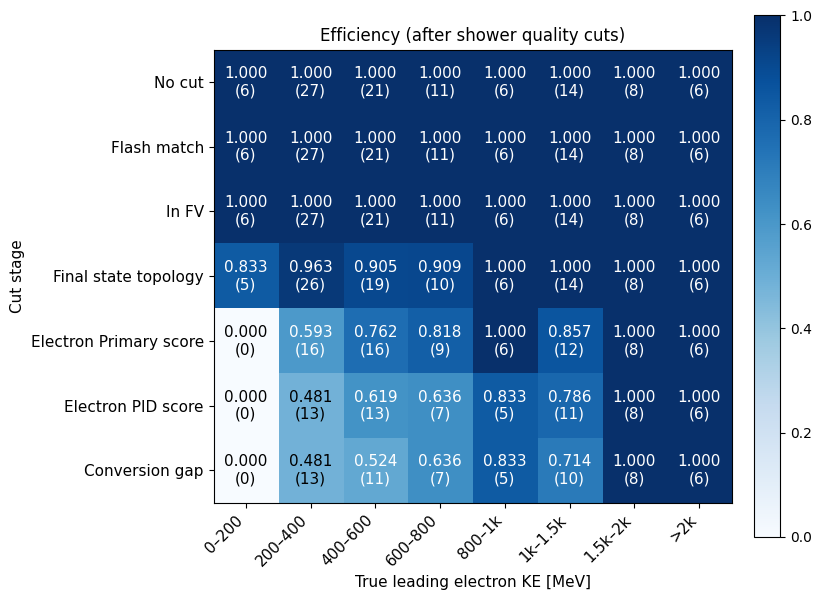

In [21]:
ke_vals_sq  = true_ke_all.reindex(presel_inter).fillna(-999).values
sig_vals_sq = (truth_cat_presel.reindex(presel_inter).fillna(7) == 0).values
stage_sel_sq = {
    cut_name: presel_inter.isin(_stage_idx_qual[cut_name])
    for cut_name in ns.CUT_NAMES_MORE
}
n_cuts = len(ns.CUT_NAMES_MORE)
ke_bins_c     = np.array([0,200,400,600,800,1000,1500,2000,np.inf])
ke_bin_labels = ["0–200","200–400","400–600","600–800",
                 "800–1k","1k–1.5k","1.5k–2k",">2k"]
n_bins = len(ke_bins_c) - 1
eff_matrix   = np.zeros((n_bins, n_cuts))
count_matrix = np.zeros((n_bins, n_cuts))
for ci, cut_name in enumerate(ns.CUT_NAMES_MORE):
    reco_sel = stage_sel_sq[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals_sq >= lo) & (ke_vals_sq < hi)
        sig_total    = (in_bin & sig_vals_sq).sum()
        sig_selected = (in_bin & sig_vals_sq & reco_sel).sum()
        eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    eff_matrix, count_matrix,
    bin_values=np.arange(n_bins), bin_labels=ke_bin_labels,
    cut_labels=ns.CUT_LABELS_MORE, remove_dummy_col=False,
    xlabel="True leading electron KE [MeV]",
    title="Efficiency (after shower quality cuts)", cmap="Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke_final", fig=fig, folder_name=PLOT_DIR)

In [22]:
purs_all, effs_all = [], []
for _name in ns.CUT_NAMES_MORE:
    _, pur, eff = _row_stats(_stage_idx_qual[_name])
    purs_all.append(pur)
    effs_all.append(eff)

fig_pe, ax_pe = plt.subplots(figsize=(9, 4))
ax_pe.plot(ns.CUT_LABELS_MORE, [p*100 for p in purs_all], "o-",  color="orange",    label="Purity [%]")
ax_pe.plot(ns.CUT_LABELS_MORE, [e*100 for e in effs_all], "s--", color="steelblue", label="Efficiency [%]")
ax_pe.set_ylim(0, 105)
ax_pe.set_xticks(range(len(ns.CUT_LABELS_MORE)))
ax_pe.set_xticklabels(ns.CUT_LABELS_MORE, rotation=30, ha="right", fontsize=9)
ax_pe.set_ylabel("Percent [%]")
ax_pe.set_title("Purity & Efficiency — all cuts")
ax_pe.legend(fontsize=9)
ax_pe.grid(alpha=0.3)
plt.tight_layout()
nh.save_plot("cutflow_pur_eff_final", fig=fig_pe, folder_name=PLOT_DIR)

fig_tab, ax_tab = plt.subplots(figsize=(9, 3.2))
nh.create_purity_efficiency_table(purs_all, effs_all, ns.CUT_LABELS_MORE, ax_tab)
fig_tab.tight_layout()
nh.save_plot("pur_eff_table_all_final", fig=fig_tab, folder_name=PLOT_DIR)

NameError: name 'truth_info' is not defined

### 5-2. Histograms

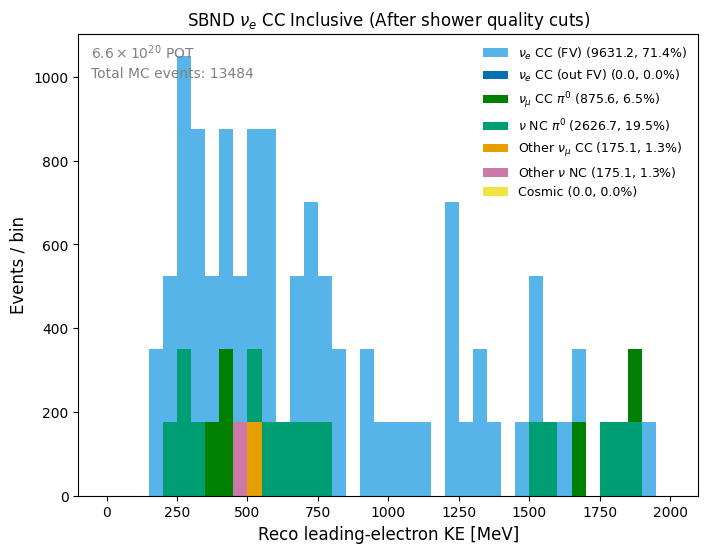

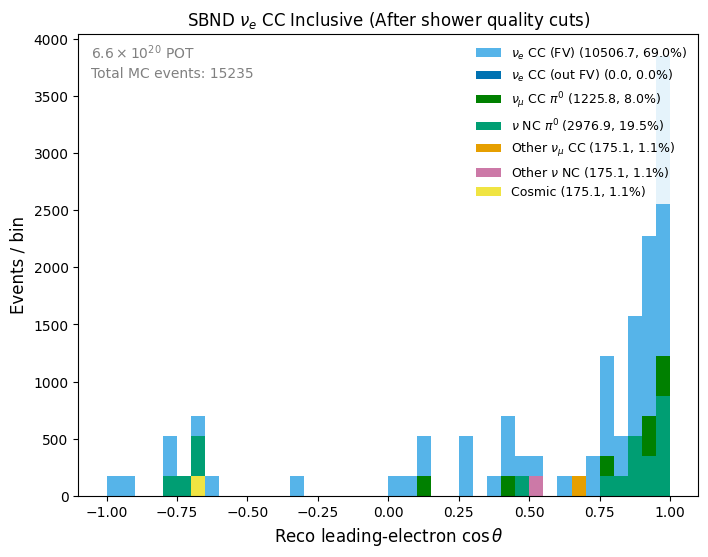

In [23]:
final_col   = f"sel_{ns.CUT_NAMES_MORE[-1]}"
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

def _qual_cat(col, cat):
    mask = sel_qual[final_col] & (sel_qual["truth_cat"] == cat)
    mask = mask & sel_qual["reco_ke"].notna() & sel_qual["reco_costheta"].notna()
    return sel_qual.loc[mask, col].values

fig_ke2, ax_ke2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.linspace(0, 2000, 41),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke_final", fig=fig_ke2, folder_name=PLOT_DIR)

fig_cos2, ax_cos2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta_final", fig=fig_cos2, folder_name=PLOT_DIR)

In [ ]:
%reset -f

In [ ]:
pause